# 05 — Interprétabilité (SHAP)

## Objectif
Expliquer les prédictions du modèle de scoring crédit avec **SHAP** (SHapley Additive exPlanations).

SHAP attribue à chaque feature une **contribution** (positive ou négative) à la prédiction finale.
C'est basé sur la théorie des jeux (valeurs de Shapley) : chaque feature est un "joueur" et on mesure
sa contribution marginale moyenne à la prédiction.

## Livrables
1. **Interprétabilité globale** : `shap.summary_plot()` — quelles features influencent le plus le modèle sur l'ensemble du dataset
2. **Interprétabilité locale** : `shap.waterfall_plot()` — pourquoi le modèle a donné ce score à **un client précis**

## 1. Imports et chargement des données

In [1]:
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from lightgbm import LGBMClassifier

# Necessaire pour afficher les plots SHAP dans Jupyter
shap.initjs()
print('Imports OK')

c:\Users\Utilisateur\Desktop\dev\oc\p6\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Imports OK


In [2]:
df = pd.read_csv('../data/train_preprocessed.csv')
print(f'Shape : {df.shape}')

y = df['TARGET']
X = df.drop(columns=['TARGET'])

# Nettoyage des noms de colonnes (coherent avec 03_modeling)
X.columns = X.columns.str.replace(r'[^A-Za-z0-9_]', '_', regex=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'X_train : {X_train.shape}')
print(f'X_test  : {X_test.shape}')

Shape : (307511, 245)
X_train : (246008, 244)
X_test  : (61503, 244)


## 2. Réentraînement du modèle optimisé

On réentraîne le LightGBM avec les meilleurs hyperparamètres trouvés dans `04_optimization.ipynb`.

**Pourquoi réentraîner ici plutôt que charger depuis MLflow ?**
Pour garder le notebook autonome et éviter les dépendances sur un run MLflow spécifique.
Les hyperparamètres sont ceux issus d'Optuna (notebook 04).

> **Note** : si les hyperparamètres changent après ré-optimisation dans 04, il faudra les mettre à jour ici.

In [3]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

# Hyperparametres optimises par Optuna (notebook 04)
best_params = {
    'n_estimators':      452,
    'max_depth':         10,
    'learning_rate':     0.03334789959637915,
    'num_leaves':        41,
    'min_child_samples': 38,
    'subsample':         0.8445691726741573,
    'colsample_bytree':  0.6409016614512465,
    'reg_alpha':         6.46378438464145,
    'reg_lambda':        0.0703691194715655,
    'scale_pos_weight':  neg / pos,
    'random_state':      42,
    'verbose':           -1,
    'n_jobs':            -1,
}

model = LGBMClassifier(**best_params)
model.fit(X_train, y_train)

from sklearn.metrics import roc_auc_score
y_proba = model.predict_proba(X_test)[:, 1]
print(f'AUC holdout : {roc_auc_score(y_test, y_proba):.4f}')

AUC holdout : 0.7781


## 3. Calcul des valeurs SHAP

On utilise `shap.TreeExplainer`, optimisé pour les modèles à base d'arbres (LightGBM, XGBoost, RF).

**Comment ça marche ?**
- Pour chaque prédiction, SHAP décompose le résultat en : `base_value + contribution_feature_1 + contribution_feature_2 + ...`
- `base_value` = la prédiction moyenne du modèle (avant de voir les features du client)
- Chaque `contribution` est positive (pousse vers TARGET=1) ou négative (pousse vers TARGET=0)

On calcule les valeurs SHAP sur **X_test** (données que le modèle n'a jamais vues pendant l'entraînement).

In [4]:
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test)
print(f'shap_values shape : {shap_values.shape}')
print(f'base_value (prediction moyenne) : {shap_values.base_values[0]:.4f}')

shap_values shape : (61503, 244)
base_value (prediction moyenne) : -0.5972


## 4. Interprétabilité globale — Summary Plot

Le `summary_plot` montre **toutes les features classées par importance SHAP** :
- Axe X : valeur SHAP (impact sur la prédiction)
- Axe Y : features classées de la plus importante à la moins importante
- Couleur : valeur de la feature (rouge = élevée, bleu = basse)

**Comment lire le graphique :**
- Si les points rouges (valeur élevée) sont à droite (SHAP positif) → une valeur élevée de cette feature **augmente** le risque de défaut
- Si les points bleus (valeur basse) sont à droite → une valeur basse **augmente** le risque

### Résultats attendus

Les **3 features EXT_SOURCE** dominent massivement le modèle (SHAP moyen combiné ~0.81, soit ~30% de l'impact total).
Ce sont des scores externes d'autres institutions financières (type score de bureau de crédit).

**Lecture des directions SHAP :**
- **EXT_SOURCE_2/3** : les points roses (valeurs hautes) tirent les SHAP vers la gauche (négatif = bon client). Un bon score externe = faible risque de défaut
- **EXT_SOURCE_1/2/3** : les points bleus (valeurs basses) tirent vers la droite (positif = mauvais client). Un mauvais score externe = risque élevé
- **DAYS_EMPLOYED** : les points bleus (valeurs très négatives = longue ancienneté) tirent vers la gauche. Plus un client est employé longtemps, moins il risque le défaut

Le **deuxième bloc** de features (SHAP ~0.08-0.13) regroupe des variables financières internes : AMT_CREDIT, AMT_GOODS_PRICE, PREV_AMT_ANNUITY_MEAN, INSTALL_DAYS_LATE_MAX. Elles apportent un signal complémentaire aux scores externes.

La **queue longue** (225 autres features) contribue +1.2 en SHAP cumulé, soit presque autant que le top 3. Le modèle capte un signal distribué sur de nombreuses petites variables — comportement typique du gradient boosting qui excelle à combiner des signaux faibles.

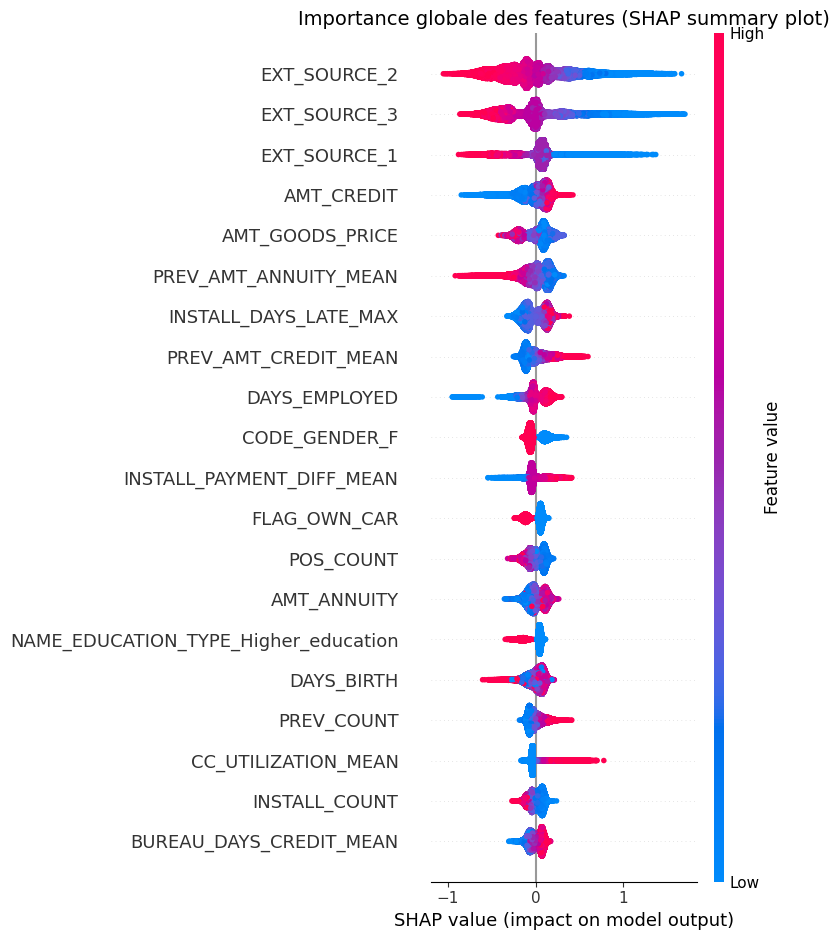

In [5]:
plt.figure(figsize=(12, 10))
shap.summary_plot(shap_values, X_test, max_display=20, show=False)
plt.title('Importance globale des features (SHAP summary plot)', fontsize=14)
plt.tight_layout()
plt.show()

### 4.1 Bar plot — Importance moyenne absolue

Version simplifiée : chaque barre = la **moyenne des |SHAP|** pour cette feature.
Plus la barre est longue, plus la feature influence les prédictions (dans un sens ou dans l'autre).

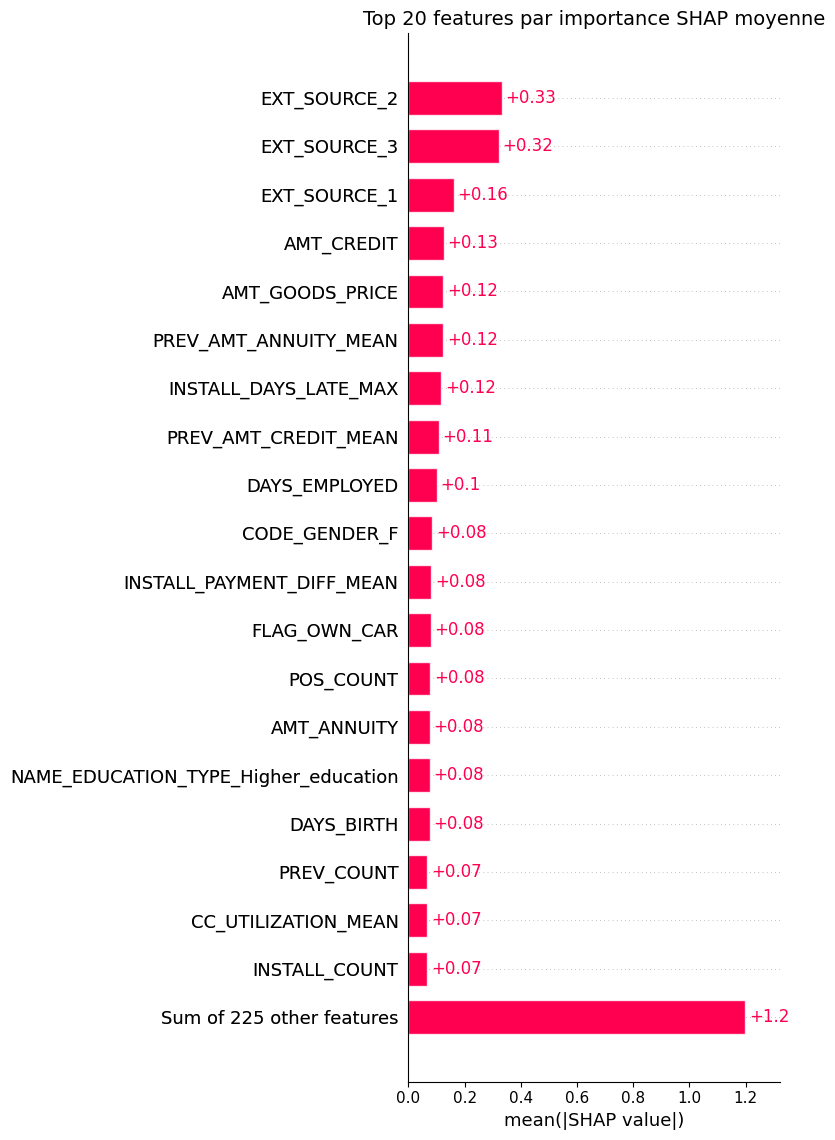

In [6]:
plt.figure(figsize=(10, 8))
shap.plots.bar(shap_values, max_display=20, show=False)
plt.title('Top 20 features par importance SHAP moyenne', fontsize=14)
plt.tight_layout()
plt.show()

## 5. Interprétabilité locale — Waterfall Plot

Le `waterfall_plot` explique **une prédiction individuelle** :
- On part de la `base_value` (prédiction moyenne)
- Chaque feature "pousse" la prédiction vers le haut (rouge) ou vers le bas (bleu)
- On arrive à la prédiction finale `f(x)` pour ce client

C'est exactement ce qu'un chargé d'études utiliserait pour **expliquer au client** pourquoi son crédit est accordé ou refusé.

### 5.1 Client à haut risque (TARGET = 1 prédit)

On sélectionne le client avec la **plus haute probabilité de défaut** prédite par le modèle.

### Analyse attendue

Le modèle part d'une baseline `E[f(X)] = -0.597` (reflet du déséquilibre : majorité de bons clients) et arrive à `f(x) = 2.812` (P(défaut) = 94.33%).

**Les 3 facteurs décisifs :**
- **EXT_SOURCE_3 = 0.025** (SHAP = +1.05) : score externe quasi nul, c'est le signal le plus fort de défaut. À lui seul, il explique ~30% de la prédiction
- **EXT_SOURCE_2 = 0.131** (SHAP = +0.61) : score externe très bas également
- **CC_UTILIZATION_MEAN = 0.782** (SHAP = +0.27) : utilisation de 78% de sa ligne de carte de crédit — signe de tension financière

**Interprétation métier** : ce client cumule des scores de crédit externes quasi nuls ET une utilisation très élevée de sa carte de crédit. C'est un profil classique de surendettement. La décision de refus est justifiable et explicable au client.

Seule **PREV_AMT_CREDIT_MEAN** (5625) pousse légèrement vers le négatif (-0.09) : ses anciens crédits étaient de petits montants, ce qui est un léger signal positif, mais insuffisant pour compenser.

In [7]:
# Trouver un client a haut risque dans X_test
y_proba_test = model.predict_proba(X_test)[:, 1]
idx_risk = np.argmax(y_proba_test)  # client avec la plus haute probabilite de defaut

print(f'Client index : {idx_risk}')
print(f'Probabilite de defaut : {y_proba_test[idx_risk]:.4f}')
print(f'TARGET reel : {y_test.iloc[idx_risk]}')

Client index : 36308
Probabilite de defaut : 0.9433
TARGET reel : 1


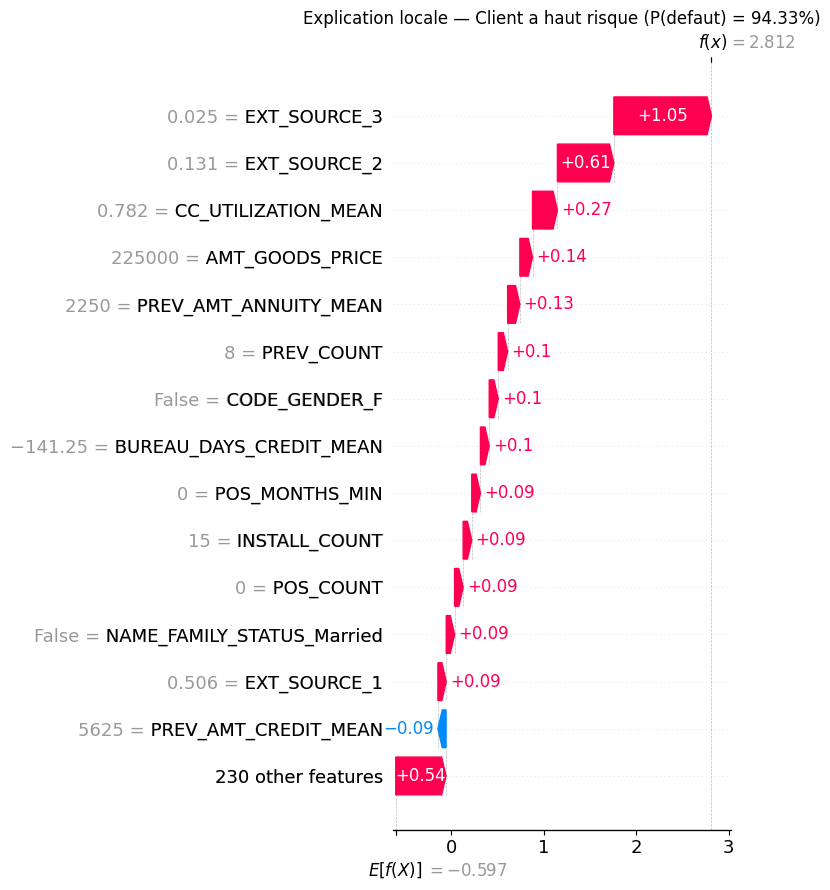

In [8]:
plt.figure(figsize=(10, 8))
shap.waterfall_plot(shap_values[idx_risk], max_display=15, show=False)
plt.title(f'Explication locale — Client a haut risque (P(defaut) = {y_proba_test[idx_risk]:.2%})', fontsize=12)
plt.tight_layout()
plt.show()

### 5.2 Client à faible risque (TARGET = 0 prédit)

On sélectionne le client avec la **plus basse probabilité de défaut**.

### Analyse attendue

Le modèle arrive à `f(x) = -4.781` (P(défaut) = 0.83%), soit une très forte confiance.

**Les facteurs protecteurs (tous négatifs = poussent vers "bon client") :**
- **EXT_SOURCE_3 = 0.863** (SHAP = -0.6) : excellent score externe
- **EXT_SOURCE_2 = 0.742** (SHAP = -0.6) : idem
- **EXT_SOURCE_1 = 0.763** (SHAP = -0.39) : les 3 scores externes sont élevés et concordants
- **NAME_CONTRACT_TYPE = 1** (SHAP = -0.35) : type de contrat favorable
- **BUREAU_CREDIT_SUM_MAX = 16 200 000** (SHAP = -0.26) : historique de crédits importants bien gérés
- **DAYS_EMPLOYED = -5557** (SHAP = -0.19) : ~15 ans d'ancienneté dans l'emploi
- **Higher_education = True** (SHAP = -0.17) : diplôme d'études supérieures
- **INSTALL_DAYS_LATE_MAX = 0** (SHAP = -0.13) : aucun retard de paiement

**Seul signal de risque** : AMT_ANNUITY = 42 750 (SHAP = +0.09) — une mensualité élevée, mais largement compensée par tout le reste.

**Interprétation métier** : profil "idéal" — bons scores externes, emploi stable depuis 15 ans, diplômé, aucun retard, historique de crédits bien gérés. La confiance du modèle à 99.17% est cohérente et explicable.

In [9]:
# Trouver un client a faible risque
idx_safe = np.argmin(y_proba_test)  # client avec la plus basse probabilite de defaut

print(f'Client index : {idx_safe}')
print(f'Probabilite de defaut : {y_proba_test[idx_safe]:.4f}')
print(f'TARGET reel : {y_test.iloc[idx_safe]}')

Client index : 7231
Probabilite de defaut : 0.0083
TARGET reel : 0


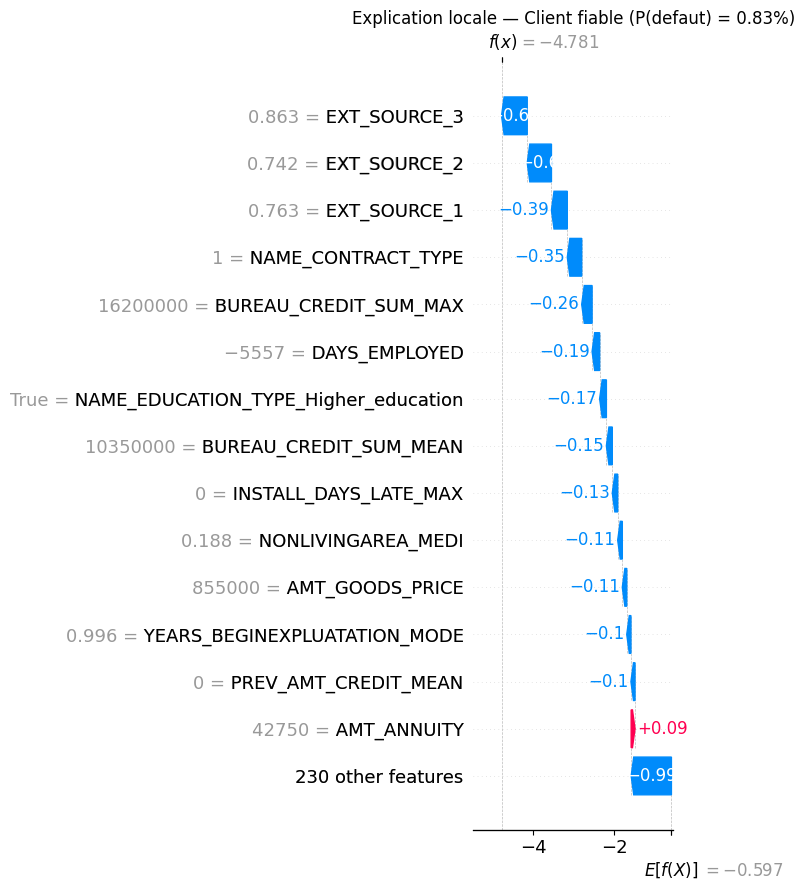

In [10]:
plt.figure(figsize=(10, 8))
shap.waterfall_plot(shap_values[idx_safe], max_display=15, show=False)
plt.title(f'Explication locale — Client fiable (P(defaut) = {y_proba_test[idx_safe]:.2%})', fontsize=12)
plt.tight_layout()
plt.show()

## 6. Conclusion

### Interprétabilité globale
- Les **EXT_SOURCE_2/3** représentent à eux seuls ~25% du pouvoir prédictif total du modèle. Ce sont des scores de crédit fournis par des institutions externes
- Les **directions SHAP sont cohérentes avec le métier** : bon score externe = bon client, ancienneté emploi élevée = bon client, retards de paiement = mauvais client
- La **queue longue** (225 features à faible SHAP individuel) contribue autant que le top 3, montrant que le gradient boosting exploite efficacement des signaux faibles distribués

### Interprétabilité locale
- Le `waterfall_plot` permet d'expliquer **chaque décision individuellement** avec les contributions précises de chaque feature
- **Client à haut risque** (94.33%) : scores externes quasi nuls + utilisation carte de crédit à 78% → profil de surendettement identifiable
- **Client fiable** (0.83%) : scores externes élevés + 15 ans d'emploi + aucun retard + diplômé → profil "idéal" cohérent
- Un chargé d'études peut montrer au client les raisons précises de l'acceptation ou du refus

### Transparence et conformité
- SHAP est une méthode **théoriquement fondée** (valeurs de Shapley, théorie des jeux) et **model-agnostic**
- Elle répond aux exigences réglementaires sur l'explicabilité des décisions de crédit (RGPD — droit à l'explication)

### Risques et recommandations
- **Dépendance aux scores externes** : si un fournisseur EXT_SOURCE change sa méthodologie ou devient indisponible, le modèle perd ~30% de son signal prédictif
- **Recommandation production** : monitorer la distribution des EXT_SOURCE (détection de data drift) et prévoir un modèle de fallback sans ces features